# AI CV Personality Analyzer
## 04 - Model Training

### Objective

This notebook trains Machine Learning models to predict the five
Big Five personality traits from CV/resume text.

The five personality traits are:

- O — Openness
- C — Conscientiousness
- E — Extraversion
- A — Agreeableness
- N — Neuroticism

### Model Training Strategy

The personality prediction problem is treated as five independent
binary classification problems.

For each personality trait, multiple Machine Learning algorithms
will be trained and compared.

### Models

1. Logistic Regression
2. Linear Support Vector Machine
3. Multinomial Naive Bayes

### Model Selection

Models will be evaluated on the validation dataset.

The best-performing model for each personality trait will be selected
based on validation F1-score.

The test dataset will NOT be used for model selection.

It will remain untouched until the final model evaluation notebook.

### Important

The feature matrices were already created in Notebook 03.

They contain:

- Word-level TF-IDF
- Character-level TF-IDF
- Text statistical features

Total features: 35,007.

## 1. Import Required Libraries

The following libraries are required for:

- Loading feature matrices
- Loading target variables
- Training classification models
- Calculating evaluation metrics
- Saving trained models
- Creating model comparison tables

In [18]:
# Import os for file and directory management
import os

# Import NumPy for numerical operations
import numpy as np

# Import pandas for DataFrame operations
import pandas as pd

# Import joblib for saving trained models
import joblib

# Import sparse matrix loader
from scipy.sparse import load_npz

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Import Linear Support Vector Machine
from sklearn.svm import LinearSVC

# Import Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Display all DataFrame columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Define Paths

The feature matrices and target variables were generated
by Notebook 03.

We will load those artifacts from the `models/` directory.

Trained personality models will also be saved in this directory.

In [19]:
# Define the models directory
MODELS_DIR = "../models"

# Define feature matrix paths
X_TRAIN_PATH = os.path.join(
    MODELS_DIR,
    "X_train.npz"
)

X_VALIDATION_PATH = os.path.join(
    MODELS_DIR,
    "X_validation.npz"
)

X_TEST_PATH = os.path.join(
    MODELS_DIR,
    "X_test.npz"
)

# Define target paths
Y_TRAIN_PATH = os.path.join(
    MODELS_DIR,
    "y_train.parquet"
)

Y_VALIDATION_PATH = os.path.join(
    MODELS_DIR,
    "y_validation.parquet"
)

Y_TEST_PATH = os.path.join(
    MODELS_DIR,
    "y_test.parquet"
)

# Create the models directory if necessary
os.makedirs(MODELS_DIR, exist_ok=True)

print("Paths configured successfully.")

Paths configured successfully.


## 3. Load Feature Matrices

Load the sparse feature matrices created in Notebook 03.

The matrices contain 35,007 features for each document.

Sparse matrices are used to reduce memory consumption because
TF-IDF representations contain a large number of zero values.

In [20]:
# Load the training feature matrix
X_train = load_npz(X_TRAIN_PATH)

# Load the validation feature matrix
X_validation = load_npz(X_VALIDATION_PATH)

# Load the test feature matrix
X_test = load_npz(X_TEST_PATH)

# Display feature matrix shapes
print("Feature Matrix Shapes")
print("-" * 50)

print("Training   :", X_train.shape)
print("Validation :", X_validation.shape)
print("Test       :", X_test.shape)

Feature Matrix Shapes
--------------------------------------------------
Training   : (1578, 35007)
Validation : (395, 35007)
Test       : (494, 35007)


## 4. Load Personality Targets

Load the Big Five personality labels created in Notebook 03.

Each personality trait is represented as a binary target:

- 0
- 1

The five traits will be trained independently.

In [21]:
# Load training personality labels
y_train = pd.read_parquet(Y_TRAIN_PATH)

# Load validation personality labels
y_validation = pd.read_parquet(Y_VALIDATION_PATH)

# Load test personality labels
y_test = pd.read_parquet(Y_TEST_PATH)

# Define the Big Five personality traits
TARGET_COLUMNS = [
    "O",
    "C",
    "E",
    "A",
    "N"
]

# Display target shapes
print("Target Shapes")
print("-" * 50)

print("Training   :", y_train.shape)
print("Validation :", y_validation.shape)
print("Test       :", y_test.shape)

print("\nTarget Columns:")
print(TARGET_COLUMNS)

Target Shapes
--------------------------------------------------
Training   : (1578, 5)
Validation : (395, 5)
Test       : (494, 5)

Target Columns:
['O', 'C', 'E', 'A', 'N']


## 5. Validate Training Data

Before training the models, verify that:

- Feature and target row counts match.
- All five personality targets exist.
- Each target contains two classes.
- No missing target values exist.

These checks help prevent training errors.

In [22]:
# Verify feature and target row counts
assert X_train.shape[0] == len(y_train)
assert X_validation.shape[0] == len(y_validation)
assert X_test.shape[0] == len(y_test)

# Verify all personality columns exist
for trait in TARGET_COLUMNS:

    if trait not in y_train.columns:
        raise ValueError(
            f"Missing target column: {trait}"
        )

# Check target classes
for trait in TARGET_COLUMNS:

    train_classes = sorted(
        y_train[trait].unique()
    )

    validation_classes = sorted(
        y_validation[trait].unique()
    )

    test_classes = sorted(
        y_test[trait].unique()
    )

    print(f"\nTrait: {trait}")
    print("Train      :", train_classes)
    print("Validation :", validation_classes)
    print("Test       :", test_classes)

print("\nTraining data validation completed successfully.")


Trait: O
Train      : [0, 1]
Validation : [0, 1]
Test       : [0, 1]

Trait: C
Train      : [0, 1]
Validation : [0, 1]
Test       : [0, 1]

Trait: E
Train      : [0, 1]
Validation : [0, 1]
Test       : [0, 1]

Trait: A
Train      : [0, 1]
Validation : [0, 1]
Test       : [0, 1]

Trait: N
Train      : [0, 1]
Validation : [0, 1]
Test       : [0, 1]

Training data validation completed successfully.


## 6. Define Candidate Machine Learning Models

Three classification algorithms will be compared.

### Logistic Regression

A strong baseline for high-dimensional sparse text features.

### Linear SVM

Often performs strongly on TF-IDF text classification problems.

### Multinomial Naive Bayes

A lightweight probabilistic model commonly used for text classification.

Each model will be trained separately for each Big Five personality trait.

In [23]:
# Create the candidate model definitions
MODEL_FACTORIES = {

    "Logistic Regression": lambda: LogisticRegression(
        C=1.0,
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Linear SVM": lambda: LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42
    ),

    "Multinomial Naive Bayes": lambda: MultinomialNB(
        alpha=1.0
    )
}

# Display available models
print("Candidate Models:")
for model_name in MODEL_FACTORIES:
    print("-", model_name)

Candidate Models:
- Logistic Regression
- Linear SVM
- Multinomial Naive Bayes


## 7. Define Evaluation Function

We will evaluate each model using:

- Accuracy
- Precision
- Recall
- F1-score

F1-score will be the primary metric for model selection because
it balances precision and recall.

The validation dataset will be used for comparing candidate models.

In [24]:
def evaluate_model(model, X_data, y_true):
    """
    Evaluate a trained classification model.

    Parameters
    ----------
    model : trained classifier
        Trained Machine Learning model.

    X_data : sparse matrix
        Feature matrix.

    y_true : array-like
        Actual target labels.

    Returns
    -------
    dict
        Classification metrics.
    """

    # Generate predictions
    y_pred = model.predict(X_data)

    # Calculate accuracy
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    # Calculate precision
    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    # Calculate recall
    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    # Calculate F1-score
    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

## 8. Train and Compare Models

For each Big Five trait:

1. Train Logistic Regression.
2. Train Linear SVM.
3. Train Multinomial Naive Bayes.
4. Evaluate each model on the validation set.
5. Store the validation metrics.

The test set is intentionally not used here.

In [25]:
# Store all validation results
validation_results = []

# Store trained candidate models
candidate_models = {}

# Train models separately for each personality trait
for trait in TARGET_COLUMNS:

    print("\n" + "=" * 70)
    print(f"Training Models for Personality Trait: {trait}")
    print("=" * 70)

    # Extract the target labels for the current trait
    y_train_trait = y_train[trait].astype(int)
    y_validation_trait = y_validation[trait].astype(int)

    # Create a dictionary for models belonging to this trait
    candidate_models[trait] = {}

    # Train every candidate model
    for model_name, model_factory in MODEL_FACTORIES.items():

        print(f"\nTraining: {model_name}")

        # Create a fresh model instance
        model = model_factory()

        # Train the model using ONLY training data
        model.fit(
            X_train,
            y_train_trait
        )

        # Evaluate using validation data
        metrics = evaluate_model(
            model,
            X_validation,
            y_validation_trait
        )

        # Save the trained model temporarily
        candidate_models[trait][model_name] = model

        # Store results
        validation_results.append({
            "Trait": trait,
            "Model": model_name,
            "Accuracy": metrics["accuracy"],
            "Precision": metrics["precision"],
            "Recall": metrics["recall"],
            "F1 Score": metrics["f1_score"]
        })

        print(
            f"Validation F1: "
            f"{metrics['f1_score']:.4f}"
        )

print("\nModel comparison completed.")


Training Models for Personality Trait: O

Training: Logistic Regression
Validation F1: 0.6165

Training: Linear SVM


c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Validation F1: 0.6110

Training: Multinomial Naive Bayes
Validation F1: 0.6546

Training Models for Personality Trait: C

Training: Logistic Regression
Validation F1: 0.6308

Training: Linear SVM


c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Validation F1: 0.6375

Training: Multinomial Naive Bayes
Validation F1: 0.6625

Training Models for Personality Trait: E

Training: Logistic Regression
Validation F1: 0.6102

Training: Linear SVM


...

Validation F1: 0.5891

Training: Multinomial Naive Bayes
Validation F1: 0.6833

Training Models for Personality Trait: A

Training: Logistic Regression
Validation F1: 0.6083

Training: Linear SVM


c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Validation F1: 0.5923

Training: Multinomial Naive Bayes
Validation F1: 0.6972

Training Models for Personality Trait: N

Training: Logistic Regression
Validation F1: 0.5947

Training: Linear SVM


c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Validation F1: 0.5368

Training: Multinomial Naive Bayes
Validation F1: 0.6067

Model comparison completed.


## 9. Display Validation Results

The following table shows the validation performance of every
candidate model for each personality trait.

The F1-score will be used to select the best model.

In [26]:
# Convert validation results into a DataFrame
validation_results_df = pd.DataFrame(
    validation_results
)

# Sort results by trait and F1-score
validation_results_df = validation_results_df.sort_values(
    by=["Trait", "F1 Score"],
    ascending=[True, False]
).reset_index(drop=True)

# Display validation results
display(validation_results_df)

,Trait,Model,Accuracy,Precision,Recall,F1 Score
0,A,Multinomial Naive Bayes,0.564557,0.551532,0.947368,0.697183
1,A,Logistic Regression,0.569620,0.586667,0.631579,0.608295
2,A,Linear SVM,0.546835,0.565217,0.622010,0.592255
3,C,Multinomial Naive Bayes,0.587342,0.567376,0.796020,0.662526
4,C,Linear SVM,0.622785,0.623810,0.651741,0.637470
5,C,Logistic Regression,0.617722,0.620192,0.641791,0.630807
6,E,Multinomial Naive Bayes,0.582278,0.561514,0.872549,0.683301
7,E,Logistic Regression,0.592405,0.602871,0.617647,0.610169
8,E,Linear SVM,0.579747,0.595000,0.583333,0.589109
9,N,Multinomial Naive Bayes,0.612658,0.617801,0.595960,0.606684


## 10. Select the Best Model for Each Personality Trait

The model with the highest validation F1-score will be selected
for each Big Five personality trait.

This means different personality traits may use different algorithms.

For example:

- O → Logistic Regression
- C → Linear SVM
- E → Logistic Regression

The actual selection will depend on the validation results.

In [27]:
# Select the best model for each personality trait
best_models = {}

# Store the best model information
best_model_summary = []

for trait in TARGET_COLUMNS:

    # Filter results for the current trait
    trait_results = validation_results_df[
        validation_results_df["Trait"] == trait
    ]

    # Select the row with the highest F1-score
    best_row = trait_results.loc[
        trait_results["F1 Score"].idxmax()
    ]

    # Get the name of the best model
    best_model_name = best_row["Model"]

    # Retrieve the trained model
    best_model = candidate_models[
        trait
    ][best_model_name]

    # Store the best model
    best_models[trait] = best_model

    # Store summary information
    best_model_summary.append({
        "Trait": trait,
        "Best Model": best_model_name,
        "Validation Accuracy": best_row["Accuracy"],
        "Validation Precision": best_row["Precision"],
        "Validation Recall": best_row["Recall"],
        "Validation F1 Score": best_row["F1 Score"]
    })

# Create summary DataFrame
best_model_summary_df = pd.DataFrame(
    best_model_summary
)

# Display the best model for each trait
display(best_model_summary_df)

,Trait,Best Model,Validation Accuracy,Validation Precision,Validation Recall,Validation F1 Score
0,O,Multinomial Naive Bayes,0.612658,0.604167,0.714286,0.654628
1,C,Multinomial Naive Bayes,0.587342,0.567376,0.796020,0.662526
2,E,Multinomial Naive Bayes,0.582278,0.561514,0.872549,0.683301
3,A,Multinomial Naive Bayes,0.564557,0.551532,0.947368,0.697183
4,N,Multinomial Naive Bayes,0.612658,0.617801,0.595960,0.606684


## 11. Visualize Model Comparison

A bar chart is created to compare validation F1-scores
across the candidate models.

This makes it easier to understand which algorithms perform
best for each personality trait.

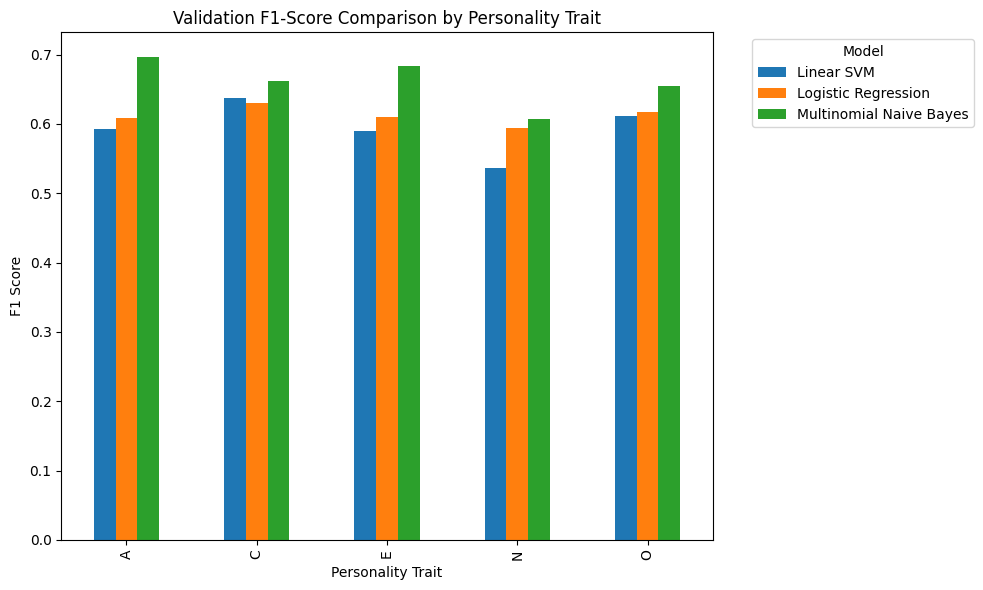

In [28]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Create a pivot table for model comparison
comparison_pivot = validation_results_df.pivot(
    index="Trait",
    columns="Model",
    values="F1 Score"
)

# Create the comparison chart
comparison_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

# Add chart title
plt.title(
    "Validation F1-Score Comparison by Personality Trait"
)

# Add axis labels
plt.xlabel("Personality Trait")
plt.ylabel("F1 Score")

# Display the legend
plt.legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Improve layout
plt.tight_layout()

# Display the chart
plt.show()

## 12. Prepare Final Training Strategy

The validation set was used only to select the best algorithm.

Now that the best algorithm is known for each personality trait,
we can retrain the selected model using the combined:

- Training dataset
- Validation dataset

This allows the final model to learn from more labeled data.

The test dataset remains completely untouched.

In [29]:
# Combine training and validation feature matrices
X_train_final = __import__("scipy.sparse").sparse.vstack([
    X_train,
    X_validation
]).tocsr()

print("Final training feature matrix:")
print(X_train_final.shape)

# Prepare combined target data
y_train_final = pd.concat(
    [
        y_train,
        y_validation
    ],
    ignore_index=True
)

print("\nFinal target matrix:")
print(y_train_final.shape)

Final training feature matrix:
(1973, 35007)

Final target matrix:
(1973, 5)


## 13. Retrain the Selected Models

Each selected model is now retrained using the combined
training and validation datasets.

This produces the final models that will later be evaluated
once on the untouched test dataset in Notebook 05.

In [30]:
# Dictionary to store the final trained models
final_models = {}

# Store information about final models
final_model_records = []

# Retrain the selected model for each personality trait
for trait in TARGET_COLUMNS:

    print("\n" + "=" * 70)
    print(f"Retraining Final Model for Trait: {trait}")
    print("=" * 70)

    # Get the selected model name
    selected_model_name = best_model_summary_df.loc[
        best_model_summary_df["Trait"] == trait,
        "Best Model"
    ].iloc[0]

    # Create a fresh model instance
    final_model = MODEL_FACTORIES[
        selected_model_name
    ]()

    # Extract combined target labels
    y_train_final_trait = (
        y_train_final[trait]
        .astype(int)
    )

    # Train using training + validation data
    final_model.fit(
        X_train_final,
        y_train_final_trait
    )

    # Store final model
    final_models[trait] = final_model

    # Store model information
    final_model_records.append({
        "Trait": trait,
        "Model": selected_model_name
    })

    print(
        f"Final model trained: "
        f"{selected_model_name}"
    )

print("\nAll final models trained successfully.")


Retraining Final Model for Trait: O
Final model trained: Multinomial Naive Bayes

Retraining Final Model for Trait: C
Final model trained: Multinomial Naive Bayes

Retraining Final Model for Trait: E
Final model trained: Multinomial Naive Bayes

Retraining Final Model for Trait: A
Final model trained: Multinomial Naive Bayes

Retraining Final Model for Trait: N
Final model trained: Multinomial Naive Bayes

All final models trained successfully.


## 14. Save Final Personality Models

Each personality trait has its own trained model.

The models are saved separately so that the dynamic application
can load all five personality predictors.

Files:

- `personality_model_O.pkl`
- `personality_model_C.pkl`
- `personality_model_E.pkl`
- `personality_model_A.pkl`
- `personality_model_N.pkl`

In [31]:
# Save each final personality model
for trait, model in final_models.items():

    # Define the model output path
    model_path = os.path.join(
        MODELS_DIR,
        f"personality_model_{trait}.pkl"
    )

    # Save the trained model
    joblib.dump(
        model,
        model_path
    )

    print(
        f"Saved {trait} model -> {model_path}"
    )

print("\nAll personality models saved successfully.")

Saved O model -> ../models\personality_model_O.pkl
Saved C model -> ../models\personality_model_C.pkl
Saved E model -> ../models\personality_model_E.pkl
Saved A model -> ../models\personality_model_A.pkl
Saved N model -> ../models\personality_model_N.pkl

All personality models saved successfully.


## 15. Save Model Selection Summary

Save the model selection results so that the final model choices
are documented and reproducible.

This file records which algorithm was selected for each personality trait.

In [32]:
# Save validation comparison results
validation_results_df.to_csv(
    os.path.join(
        MODELS_DIR,
        "model_comparison.csv"
    ),
    index=False
)

# Save final model selection summary
best_model_summary_df.to_csv(
    os.path.join(
        MODELS_DIR,
        "best_model_summary.csv"
    ),
    index=False
)

print("Model selection results saved successfully.")

Model selection results saved successfully.


## 16. Verify Saved Models

Reload each saved personality model to confirm that the model files
are valid and can be loaded successfully.

This is important because these models will later be used by the
dynamic CV analysis application.

In [33]:
# Verify every saved personality model
for trait in TARGET_COLUMNS:

    # Build the model path
    model_path = os.path.join(
        MODELS_DIR,
        f"personality_model_{trait}.pkl"
    )

    # Reload the model
    loaded_model = joblib.load(
        model_path
    )

    # Verify that the model can make predictions
    sample_prediction = loaded_model.predict(
        X_test[:1]
    )

    print(
        f"{trait} model verified successfully. "
        f"Sample prediction: {sample_prediction[0]}"
    )

print("\nAll saved models verified successfully.")

O model verified successfully. Sample prediction: 0
C model verified successfully. Sample prediction: 1
E model verified successfully. Sample prediction: 1
A model verified successfully. Sample prediction: 1
N model verified successfully. Sample prediction: 1

All saved models verified successfully.


# 17. Final Model Training Summary

The model training pipeline is complete.

### Process

Feature Matrices
↓
Candidate Models
↓
Logistic Regression
Linear SVM
Multinomial Naive Bayes
↓
Validation Evaluation
↓
Best Model Selected for Each Trait
↓
Training + Validation Data
↓
Final Model
↓
Saved Personality Models

### Personality Models

One final model is maintained for each Big Five personality trait:

- O — Openness
- C — Conscientiousness
- E — Extraversion
- A — Agreeableness
- N — Neuroticism

### Important

The test dataset has NOT been used for model selection.

The untouched test dataset will be evaluated in:

**`05_model_evaluation.ipynb`**

That notebook will provide the final unbiased performance
of the complete personality prediction system.